## Get Salzburg boundary and road netwrok
From OSM: https://pythongis.org/part2/chapter-09/nb/00-retrieving-osm-data.html

In [1]:
import osmnx as ox

In [2]:
place = "Salzburg, Austria"
aoi = ox.geocoder.geocode_to_gdf(place)

In [3]:
aoi.explore()

In [4]:
graph = ox.graph.graph_from_place(place)

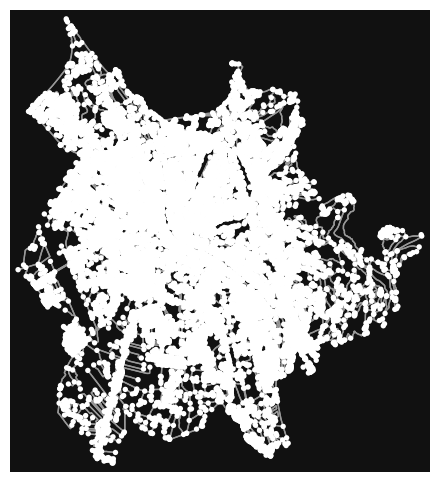

In [5]:
# Plot the streets
fig, ax = ox.plot.plot_graph(graph, figsize=(6, 6))

In [115]:
nodes, edges = ox.graph_to_gdfs(graph)

Salzburg UTM EPSG: https://de.wikipedia.org/wiki/%C3%96sterreichisches_Bundesmeldenetz

Grid from gdf boundaries: https://dmnfarrell.github.io/plotting/geopandas-grids

In [7]:
def reassign_grid_id(grid_gdf):
    import geopandas as gpd

    # grid_gdf = your grid GeoDataFrame

    # Use centroid coordinates for sorting
    grid_gdf["centroid_x"] = grid_gdf.geometry.centroid.x
    grid_gdf["centroid_y"] = grid_gdf.geometry.centroid.y

    # Sort from top-left:
    # y descending = top to bottom
    # x ascending = left to right
    grid_gdf = grid_gdf.sort_values(
        by=["centroid_y", "centroid_x"],
        ascending=[False, True]
    ).reset_index(drop=True)

    # Assign grid IDs
    grid_gdf["grid_id"] = range(1, len(grid_gdf) + 1)

    # Optional: remove helper columns
    grid_gdf = grid_gdf.drop(columns=["centroid_x", "centroid_y"])
    return grid_gdf

In [8]:
import numpy as np
def create_grid(gdf=None, bounds=None, n_cells=10, overlap=False, crs="EPSG:29902"):
    """Create square grid that covers a geodataframe area
    or a fixed boundary with x-y coords
    returns: a GeoDataFrame of grid polygons
    see https://james-brennan.github.io/posts/fast_gridding_geopandas/
    """

    import geopandas as gpd
    import shapely

    if bounds != None:
        xmin, ymin, xmax, ymax= bounds
    else:
        xmin, ymin, xmax, ymax= gdf.total_bounds

    # get cell size
    cell_size = (xmax-xmin)/n_cells
    # create the cells in a loop
    grid_cells = []
    for x0 in np.arange(xmin, xmax+cell_size, cell_size):
        for y0 in np.arange(ymin, ymax+cell_size, cell_size):
            x1 = x0-cell_size
            y1 = y0+cell_size
            poly = shapely.geometry.box(x0, y0, x1, y1)
            #print (gdf.overlay(poly, how='intersection'))
            grid_cells.append(poly)

    cells = gpd.GeoDataFrame(grid_cells, columns=['geometry'],
                                     crs=crs)
    # cells["grid_area"] = round(cells.area/10000,1)
    
    if overlap == True:
        # cols = ['grid_id','geometry','grid_area']
        cells = cells.sjoin(gdf, how='inner').drop_duplicates('geometry')
        cells = cells[[cells.geometry.name]]
        cells = cells.reset_index().rename(columns={"index": "grid_id"})
        cells["grid_area_ha"] = round(cells.area/10_000,1)
    return cells

def create_hex_grid(gdf=None, bounds=None, n_cells=10, overlap=False, crs="EPSG:29902"):
    """Hexagonal grid over geometry.
    See https://sabrinadchan.github.io/data-blog/building-a-hexagonal-cartogram.html
    """

    from shapely.geometry import Polygon
    import geopandas as gpd
    if bounds != None:
        xmin, ymin, xmax, ymax= bounds
    else:
        xmin, ymin, xmax, ymax= gdf.total_bounds

    unit = (xmax-xmin)/n_cells
    a = np.sin(np.pi / 3)
    cols = np.arange(np.floor(xmin), np.ceil(xmax), 3 * unit)
    rows = np.arange(np.floor(ymin) / a, np.ceil(ymax) / a, unit)

    #print (len(cols))
    hexagons = []
    for x in cols:
      for i, y in enumerate(rows):
        if (i % 2 == 0):
          x0 = x
        else:
          x0 = x + 1.5 * unit

        hexagons.append(Polygon([
          (x0, y * a),
          (x0 + unit, y * a),
          (x0 + (1.5 * unit), (y + unit) * a),
          (x0 + unit, (y + (2 * unit)) * a),
          (x0, (y + (2 * unit)) * a),
          (x0 - (0.5 * unit), (y + unit) * a),
        ]))

    grid = gpd.GeoDataFrame({'geometry': hexagons},crs=crs)
    if overlap == True:
        cols = ['grid_id','geometry','grid_area']
        grid = grid.sjoin(gdf, how='inner').drop_duplicates('geometry')
        
        grid = grid[[grid.geometry.name]]
        grid = reassign_grid_id(grid)
        # grid = grid.reset_index().rename(columns={"index": "grid_id"})
        grid["grid_area_ha"] = round(grid.area/10_000,1)
    return grid

In [9]:
# import pylab as plt
epsg = "EPSG:31258" # 25833
aoi_utm = aoi.to_crs(epsg) 

# grid_utm = create_grid(aoi_utm, n_cells=75, overlap=True, crs=epsg)
grid_utm = create_hex_grid(aoi_utm, n_cells=30, overlap=True, crs=epsg)
grid = grid_utm.to_crs("EPSG:4326")
print(len(grid))

244


In [10]:
# grid.explore()

<Axes: >

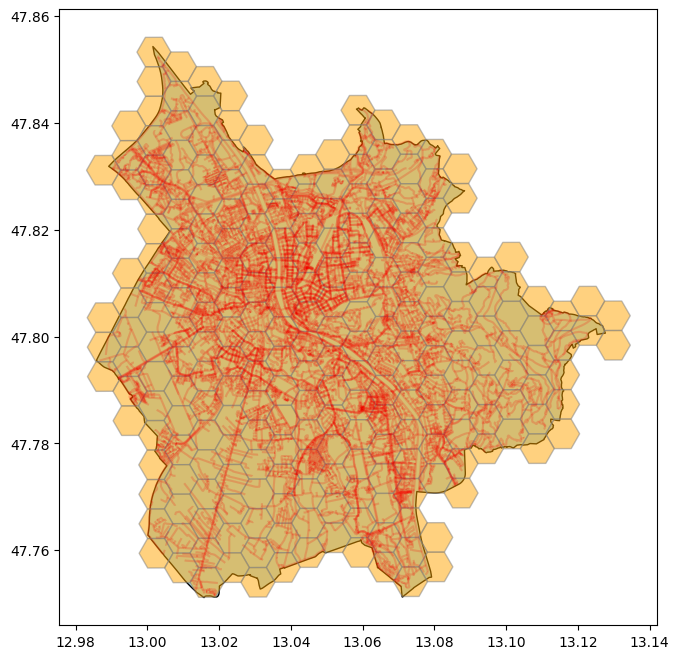

In [11]:
ax = aoi.plot(color='lightblue', edgecolor='black', figsize=(10, 8))
edges.plot(ax=ax, color='red', alpha=0.1)
grid.plot(ax=ax, color='orange', edgecolor='gray', alpha=0.5)

## Shortest path between two points
Find closest node to specified coordinates : https://www.geeksforgeeks.org/python/find-the-nearest-node-to-a-point-using-osmnx-distance-module/

Shortest path doc: https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html

Shortest path example: https://colab.research.google.com/github/mobook/MO-book/blob/main/notebooks/04/09-shortest-path-road-networks.ipynb#scrollTo=ZjGPTLE1T4gz

In [64]:
origin_coords = (47.785, 13.05)
destination_coords = (47.812095362297846, 13.061987162495239)

In [65]:
import random
random.seed(42) 

no_hazard_zones = 40
no_safety_zones = 5 
no_zones = len(grid)
    
safety_grids = []
hazard_grids = []

while len(hazard_grids) != no_hazard_zones:
    id = random.randint(1, no_zones)
    hazard_grids.append(id)
    hazard_grids = list(set(hazard_grids))
    
print(hazard_grids)

while len(safety_grids) != no_safety_zones:
    id = random.randint(1, no_zones)
    if id not in (hazard_grids):
        safety_grids.append(id)
        safety_grids = list(set(safety_grids))
    
print(safety_grids)
print(list(set(safety_grids) & set(hazard_grids)))

[130, 2, 7, 8, 9, 140, 144, 23, 152, 24, 151, 155, 27, 29, 164, 36, 167, 41, 174, 51, 180, 179, 56, 184, 58, 57, 60, 189, 190, 63, 195, 71, 72, 207, 208, 223, 229, 108, 109, 115]
[98, 196, 40, 87, 88]
[]


In [66]:
hazard_grids_gdf = grid[grid['grid_id'].isin(hazard_grids)]
hazard_grids_gdf.head()

,geometry,grid_id,grid_area_ha
1,"POLYGON ((13.0066 47.84776, 13.01133 47.84777,...",2,32.6
6,"POLYGON ((12.99955 47.83946, 13.00428 47.83947...",7,32.6
7,"POLYGON ((13.01375 47.8395, 13.01849 47.83951,...",8,32.6
8,"POLYGON ((13.05636 47.83961, 13.06109 47.83962...",9,32.6
22,"POLYGON ((13.0635 47.83135, 13.06823 47.83136,...",23,32.6


In [67]:
safety_grids_gdf = grid[grid['grid_id'].isin(safety_grids)]
safety_grids_gdf.head()

,geometry,grid_id,grid_area_ha
39,"POLYGON ((12.99966 47.8229, 13.00439 47.82291,...",40,32.6
86,"POLYGON ((13.08492 47.80655, 13.08965 47.80656...",87,32.6
87,"POLYGON ((13.09911 47.80658, 13.10384 47.80659...",88,32.6
97,"POLYGON ((13.12041 47.80387, 13.12514 47.80387...",98,32.6
195,"POLYGON ((13.02834 47.77329, 13.03307 47.77331...",196,32.6


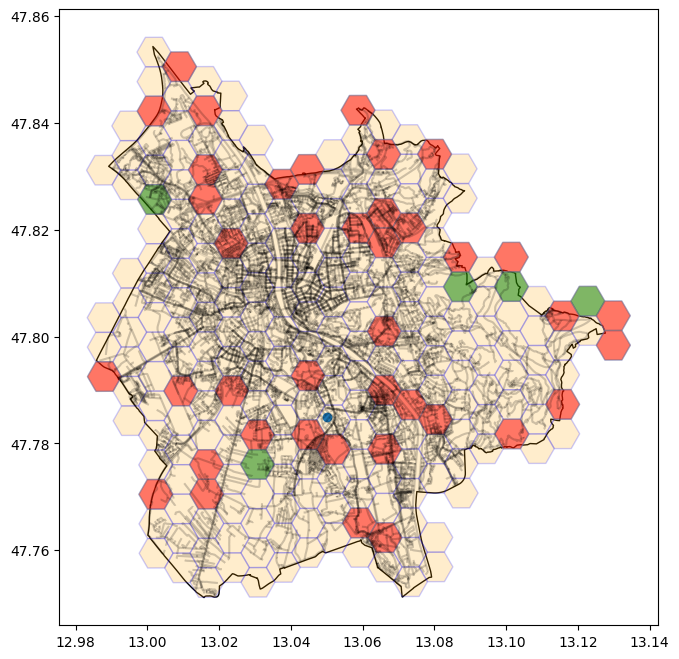

In [68]:
ax = aoi.plot(color='white', edgecolor='black', figsize=(10, 8))
edges.plot(ax=ax, color='black', alpha=0.1)
grid.plot(ax=ax, color='orange', edgecolor='blue', alpha=0.2)
hazard_grids_gdf.plot(ax=ax, color='red', edgecolor='gray', alpha=0.5)
safety_grids_gdf.plot(ax=ax, color='green', edgecolor='gray', alpha=0.5)
ax.scatter(origin_coords[1], origin_coords[0])

In [87]:
import networkx as nx
# Get centroid coordinates
centroids = [
    (point.x, point.y)
    for point in safety_grids_gdf.geometry.centroid
]

# Get nearest graph node for each centroid
destination_nodes = [
    ox.distance.nearest_nodes(graph, x, y)
    for x, y in centroids
]

origin_node = ox.distance.nearest_nodes(graph,
                                         origin_coords[1], origin_coords[0],
                                         return_dist=True)

origin_node_id = origin_node[0]

# Calculate network distance from origin to each destination
distances = []

for node in destination_nodes:
    try:
        distance = nx.shortest_path_length(
            graph,
            origin_node_id,
            node,
            weight="length"
        )
        distances.append(distance)
    except nx.NetworkXNoPath:
        distances.append(float("inf"))

# Find closest destination
closest_idx = min(range(len(distances)), key=distances.__getitem__)

destination_node_id = destination_nodes[closest_idx]
closest_distance = distances[closest_idx]

print("Closest destination:", destination_node_id)
print("Closest distance:", closest_distance)

shortest_path = ox.shortest_path(
    graph,
    origin_node_id,
    destination_node_id,
    weight="length"
)

shortest_path_edges = ox.routing.route_to_gdf(
    graph,
    shortest_path,
    weight="length"
)


C:\Users\jedimadistinction\AppData\Local\Temp\ipykernel_41488\1023319337.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for point in safety_grids_gdf.geometry.centroid


Closest destination: 1312803373
Closest distance: 2530.9995948834503


<Axes: >

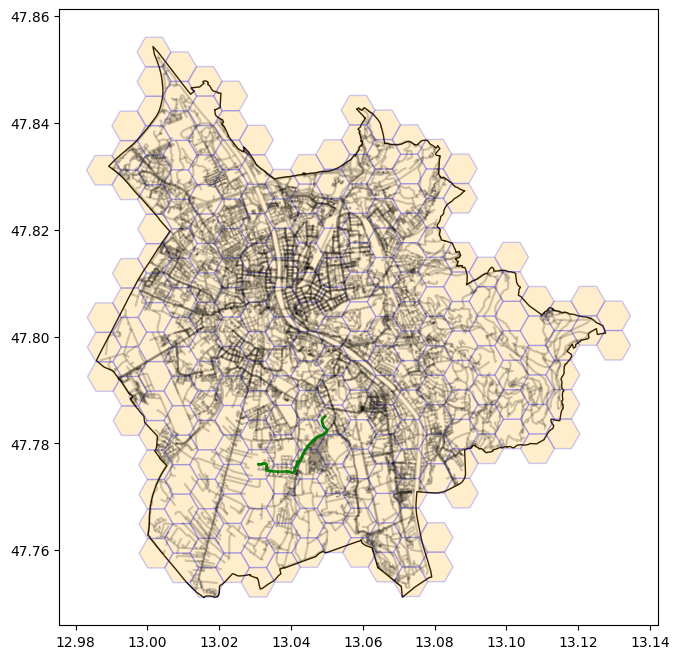

In [88]:
shortest_path = ox.shortest_path(graph, origin_node_id, destination_node_id)
shortest_path_edges = ox.routing.route_to_gdf(graph, shortest_path, weight='length')

ax = aoi.plot(color='white', edgecolor='black', figsize=(10, 8))
edges.plot(ax=ax, color='black', alpha=0.1)
grid.plot(ax=ax, color='orange', edgecolor='blue', alpha=0.2)
shortest_path_edges.plot(ax=ax, color='green', linewidth=2, alpha=1)

## Hazardous grid -> New route

In [106]:

ALLOWED_HIGHWAYS = {
    "Drive": {
        "motorway",
        "motorway_link",
        "trunk",
        "trunk_link",
        "primary",
        "primary_link",
        "secondary",
        "secondary_link",
        "tertiary",
        "tertiary_link",
        "unclassified",
        "residential",
        "living_street",
        "service",
    },
    "Bike": {
        "cycleway",
        "path",
        "living_street",
        "residential",
        "service",
        "unclassified",
        "tertiary",
        "tertiary_link",
        "secondary",
        "secondary_link",
    },
    "Walk": {
        "footway",
        "pedestrian",
        "steps",
        "path",
        "track",
        "cycleway",
        "living_street",
        "residential",
        "service",
        "unclassified",
        "tertiary",
        "tertiary_link",
    },
}


In [109]:
ALLOWED_HIGHWAYS['Drive']

{'living_street',
 'motorway',
 'motorway_link',
 'primary',
 'primary_link',
 'residential',
 'secondary',
 'secondary_link',
 'service',
 'tertiary',
 'tertiary_link',
 'trunk',
 'trunk_link',
 'unclassified'}

In [119]:
ALLOWED_HIGHWAYS.get('Drive')

{'living_street',
 'motorway',
 'motorway_link',
 'primary',
 'primary_link',
 'residential',
 'secondary',
 'secondary_link',
 'service',
 'tertiary',
 'tertiary_link',
 'trunk',
 'trunk_link',
 'unclassified'}

In [ ]:
import geopandas as gpd


for gdf in [nodes, edges, hazard_grids_gdf]:
    gdf.drop(
        columns=["index_left", "index_right"],
        errors="ignore",
        inplace=True
    )

nodes_in_hazard = gpd.sjoin(
    nodes,
    hazard_grids_gdf,
    predicate="within",
    how="inner"
)

safe_graph = graph.copy()
safe_graph.remove_nodes_from(nodes_in_hazard.index)

edges_in_hazard = gpd.sjoin(
    edges,
    hazard_grids_gdf,
    predicate="intersects",
    how="inner"
)

safe_graph.remove_edges_from(edges_in_hazard.index)

isolated_nodes = list(nx.isolates(safe_graph))
safe_graph.remove_nodes_from(isolated_nodes)


In [ ]:
def mode_filter_graph(graph, transport_mode):
    allowed = ALLOWED_HIGHWAYS[transport_mode]

    edges_to_remove = []

    for u, v, k, data in graph.edges(keys=True, data=True):
        highway = data.get("highway")

        # highway can sometimes be a list
        if isinstance(highway, list):
            valid = any(h in allowed for h in highway)
        else:
            valid = highway in allowed

        if not valid:
            edges_to_remove.append((u, v, k))

    graph = graph.copy()
    graph.remove_edges_from(edges_to_remove)

    return graph


In [89]:
# Calculate network distance from origin to each destination
distances = []

for node in destination_nodes:
    try:
        distance = nx.shortest_path_length(
            safe_graph,
            origin_node_id,
            node,
            weight="length"
        )
        distances.append(distance)
    except nx.NetworkXNoPath:
        distances.append(float("inf"))

# Find closest destination
closest_idx = min(range(len(distances)), key=distances.__getitem__)

destination_node_id = destination_nodes[closest_idx]
closest_distance = distances[closest_idx]

print("Closest destination:", destination_node_id)
print("Closest distance:", closest_distance)

safe_shortest_path = ox.shortest_path(
    safe_graph,
    origin_node_id,
    destination_node_id,
    weight="length"
)

safe_shortest_path_edges = ox.routing.route_to_gdf(
    safe_graph,
    safe_shortest_path,
    weight="length"
)

safest_distance = safe_shortest_path_edges.to_crs("EPSG:3857").length.sum()

print("Safest distance:", safest_distance)


Closest destination: 1312803373
Closest distance: 3465.193847718418
Safest distance: 5162.706959628653


<Axes: >

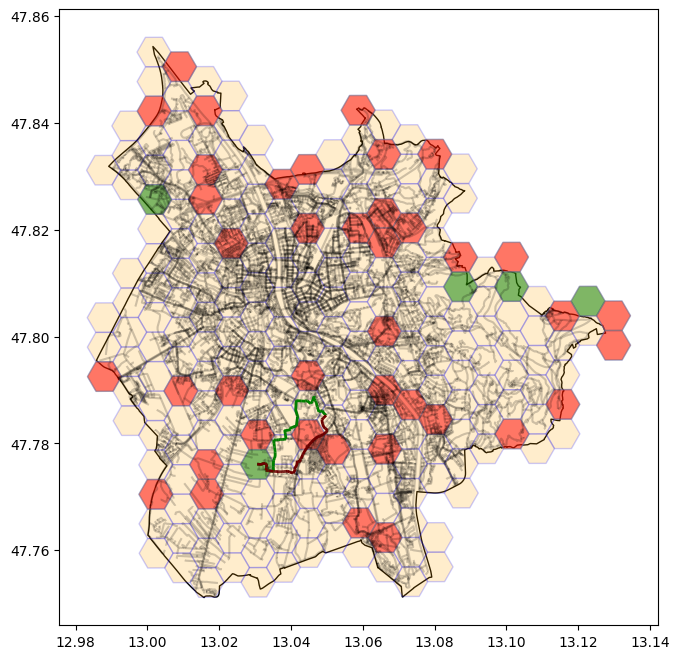

In [90]:
ax = aoi.plot(color='white', edgecolor='black', figsize=(10, 8))
edges.plot(ax=ax, color='black', alpha=0.1)
grid.plot(ax=ax, color='orange', edgecolor='blue', alpha=0.2)
hazard_grids_gdf.plot(ax=ax, color='red', edgecolor='gray', alpha=0.5)
safety_grids_gdf.plot(ax=ax, color='green', edgecolor='gray', alpha=0.5)
safe_shortest_path_edges.plot(ax=ax, color='green', linewidth=2, alpha=1)
shortest_path_edges.plot(ax=ax, color="#6E0000", linewidth=2, alpha=1)

In [113]:
len(shortest_path_edges[shortest_path_edges["highway"].isin(ALLOWED_HIGHWAYS['Drive'])])
# len(shortest_path_edges[shortest_path_edges["highway"] == "residential"])

32

<Axes: >

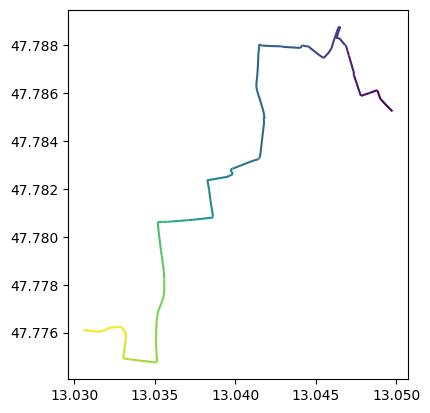

In [91]:
safe_shortest_path_edges['segment_id'] = safe_shortest_path_edges.reset_index().index
safe_shortest_path_edges.plot(column='segment_id')

In [79]:
# safe_shortest_path_edges.explore()